In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
url = "https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/001/125/original/aerofit_treadmill.csv?1639992749"

In [3]:
df = pd.read_csv(url)

In [4]:
# 1. Import the dataset and do usual data analysis steps like checking the structure & characteristics of the dataset
#number of rows and columns given in the dataset
df.shape

(180, 9)

In [5]:
#the data type of each column present in the dataset
df.dtypes

Product          object
Age               int64
Gender           object
Education         int64
MaritalStatus    object
Usage             int64
Fitness           int64
Income            int64
Miles             int64
dtype: object

In [6]:
# Check for the missing values and find the number of missing values in each column
df.isnull().sum()

Product          0
Age              0
Gender           0
Education        0
MaritalStatus    0
Usage            0
Fitness          0
Income           0
Miles            0
dtype: int64

In [7]:
df.head()

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles
0,KP281,18,Male,14,Single,3,4,29562,112
1,KP281,19,Male,15,Single,2,3,31836,75
2,KP281,19,Female,14,Partnered,4,3,30699,66
3,KP281,19,Male,12,Single,3,3,32973,85
4,KP281,20,Male,13,Partnered,4,2,35247,47


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Product        180 non-null    object
 1   Age            180 non-null    int64 
 2   Gender         180 non-null    object
 3   Education      180 non-null    int64 
 4   MaritalStatus  180 non-null    object
 5   Usage          180 non-null    int64 
 6   Fitness        180 non-null    int64 
 7   Income         180 non-null    int64 
 8   Miles          180 non-null    int64 
dtypes: int64(6), object(3)
memory usage: 12.8+ KB


In [9]:
#average value of each numeric column in the dataset
df.describe()

,Age,Education,Usage,Fitness,Income,Miles
count,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000
mean,28.788889,15.572222,3.455556,3.311111,53719.577778,103.194444
std,6.943498,1.617055,1.084797,0.958869,16506.684226,51.863605
min,18.000000,12.000000,2.000000,1.000000,29562.000000,21.000000
25%,24.000000,14.000000,3.000000,3.000000,44058.750000,66.000000
50%,26.000000,16.000000,3.000000,3.000000,50596.500000,94.000000
75%,33.000000,16.000000,4.000000,4.000000,58668.000000,114.750000
max,50.000000,21.000000,7.000000,5.000000,104581.000000,360.000000


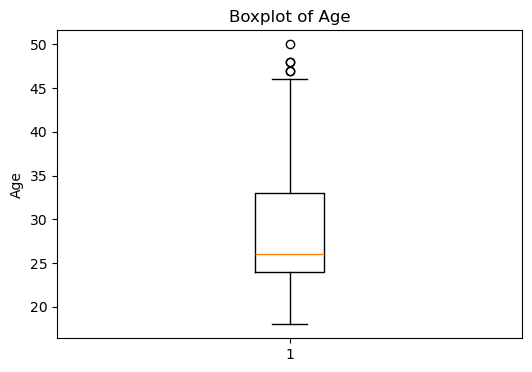

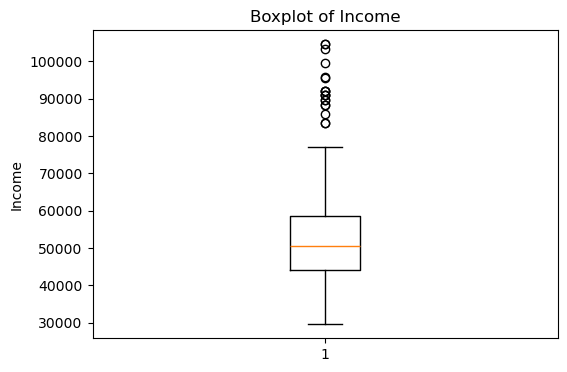

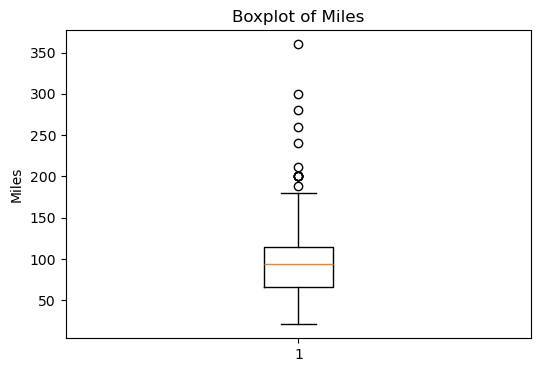

In [10]:
#DETECT OUTLIERS
#outliers in the dataset
import matplotlib.pyplot as plt

continuous_cols = ["Age", "Income", "Miles"]

for col in continuous_cols:
    plt.figure(figsize=(6, 4))
    plt.boxplot(df[col])
    plt.title(f"Boxplot of {col}")
    plt.ylabel(col)
    plt.show()

In [11]:
#clip the data between the 5 percentile and 95 percentile
import numpy as np

for col in continuous_cols:
    lower = df[col].quantile(0.05)
    upper = df[col].quantile(0.95)

    df[col] = np.clip(df[col], lower, upper)

    print(f"{col}: clipped between {lower} and {upper}")

Age: clipped between 20.0 and 43.04999999999998
Income: clipped between 34053.15 and 90948.24999999999
Miles: clipped between 47.0 and 200.0


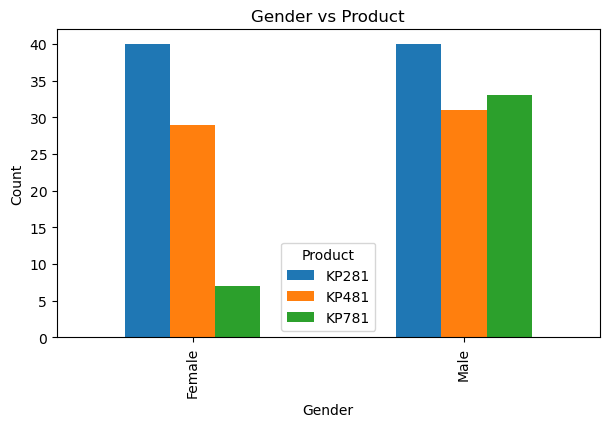

In [12]:
#Gender vs Product
counts_gender = df.groupby(["Gender", "Product"]).size().unstack(fill_value=0)
counts_gender.plot(kind="bar", figsize=(7,4))
plt.title("Gender vs Product")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

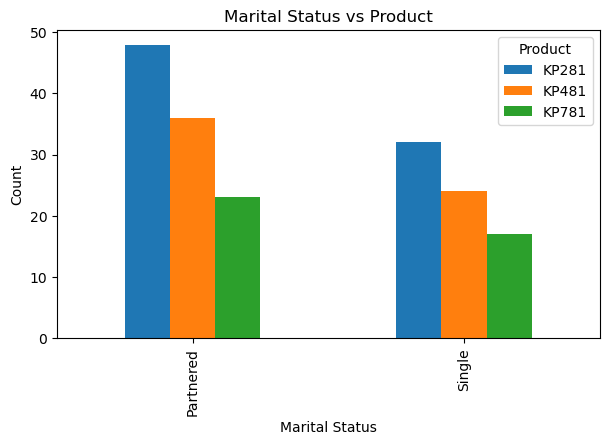

In [13]:
#MaritalStatus vs Product
counts_marital = df.groupby(["MaritalStatus", "Product"]).size().unstack(fill_value=0)
counts_marital.plot(kind="bar", figsize=(7,4))
plt.title("Marital Status vs Product")
plt.xlabel("Marital Status")
plt.ylabel("Count")
plt.show()

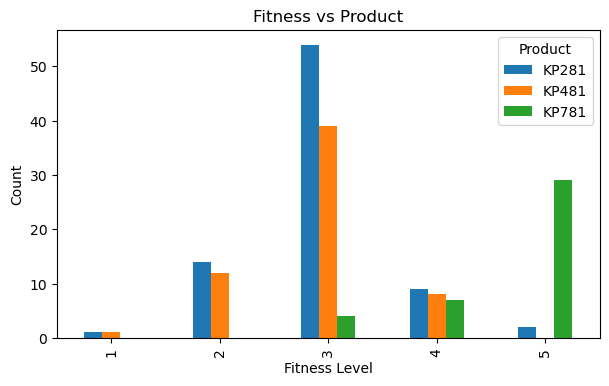

In [14]:
#Fitness vs Product
counts_fitness = df.groupby(["Fitness", "Product"]).size().unstack(fill_value=0)
counts_fitness.plot(kind="bar", figsize=(7,4))
plt.title("Fitness vs Product")
plt.xlabel("Fitness Level")
plt.ylabel("Count")
plt.show()

In [15]:
#output variable into numeric code
df["Product_Code"] = df["Product"].astype("category").cat.codes

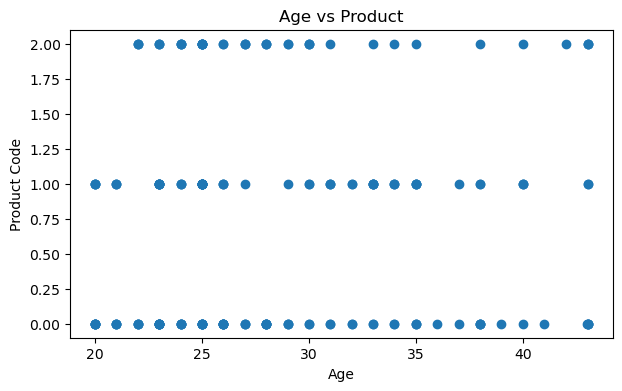

In [16]:
#Age vs Product
plt.figure(figsize=(7,4))
plt.scatter(df["Age"], df["Product_Code"])
plt.title("Age vs Product")
plt.xlabel("Age")
plt.ylabel("Product Code")
plt.show()

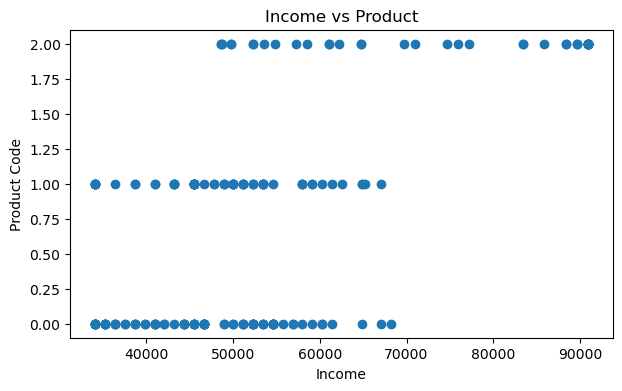

In [17]:
#Income vs Product
plt.figure(figsize=(7,4))
plt.scatter(df["Income"], df["Product_Code"])
plt.title("Income vs Product")
plt.xlabel("Income")
plt.ylabel("Product Code")
plt.show()

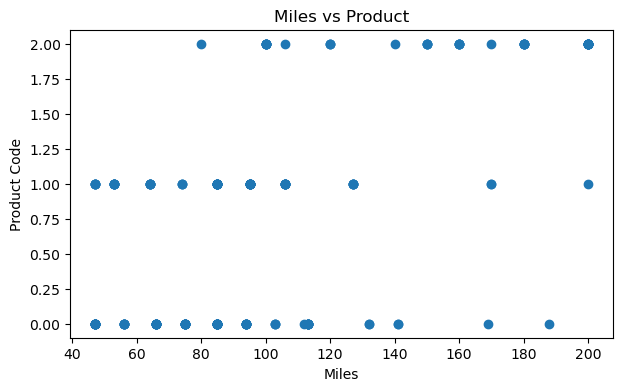

In [18]:
#Miles vs Product
plt.figure(figsize=(7,4))
plt.scatter(df["Miles"], df["Product_Code"])
plt.title("Miles vs Product")
plt.xlabel("Miles")
plt.ylabel("Product Code")
plt.show()

In [19]:
pd.crosstab(index=df["Product"], columns="count", normalize=True) * 100

col_0,count
Product,
KP281,44.444444
KP481,33.333333
KP781,22.222222


In [20]:
#Probability of each Product for each Gender
pd.crosstab(df["Gender"], df["Product"], normalize="index") * 100

Product,KP281,KP481,KP781
Gender,,,
Female,52.631579,38.157895,9.210526
Male,38.461538,29.807692,31.730769


In [21]:
#Product probability for each Fitness level
pd.crosstab(df["Fitness"], df["Product"], normalize="index") * 100

Product,KP281,KP481,KP781
Fitness,,,
1,50.000000,50.000000,0.000000
2,53.846154,46.153846,0.000000
3,55.670103,40.206186,4.123711
4,37.500000,33.333333,29.166667
5,6.451613,0.000000,93.548387


In [22]:
#Product probability for each Marital Status
pd.crosstab(df["MaritalStatus"], df["Product"], normalize="index") * 100

Product,KP281,KP481,KP781
MaritalStatus,,,
Partnered,44.859813,33.644860,21.495327
Single,43.835616,32.876712,23.287671


In [23]:
#Given that a customer is Female, what is the probability she buys KP481?
gender_prob = pd.crosstab(df["Gender"], df["Product"], normalize="index")
gender_prob.loc["Female", "KP481"]

np.float64(0.3815789473684211)

In [24]:
#Given customer has Fitness = 5, what is the probability they buy KP781?
fitness_prob = pd.crosstab(df["Fitness"], df["Product"], normalize="index")
fitness_prob.loc[5, "KP781"]

np.float64(0.9354838709677419)

In [25]:
#Given Age, what product do they buy?
age_prob = pd.crosstab(df["Age"], df["Product"], normalize="index")
age_prob

Product,KP281,KP481,KP781
Age,,,
20.00,0.600000,0.400000,0.000000
21.00,0.571429,0.428571,0.000000
22.00,0.571429,0.000000,0.428571
23.00,0.444444,0.388889,0.166667
24.00,0.416667,0.250000,0.333333
25.00,0.280000,0.440000,0.280000
26.00,0.583333,0.250000,0.166667
27.00,0.428571,0.142857,0.428571
28.00,0.666667,0.000000,0.333333


In [26]:

#Find the correlation between numeric variables
corr_matrix = df.select_dtypes(include=np.number).corr()
corr_matrix

,Age,Education,Usage,Fitness,Income,Miles,Product_Code
Age,1.000000,0.279533,0.018020,0.059047,0.514362,0.029636,0.027065
Education,0.279533,1.000000,0.395155,0.410581,0.628908,0.367262,0.495018
Usage,0.018020,0.395155,1.000000,0.668606,0.527707,0.786269,0.537447
Fitness,0.059047,0.410581,0.668606,1.000000,0.535945,0.822393,0.594883
Income,0.514362,0.628908,0.527707,0.535945,1.000000,0.537297,0.627597
Miles,0.029636,0.367262,0.786269,0.822393,0.537297,1.000000,0.593494
Product_Code,0.027065,0.495018,0.537447,0.594883,0.627597,0.593494,1.000000


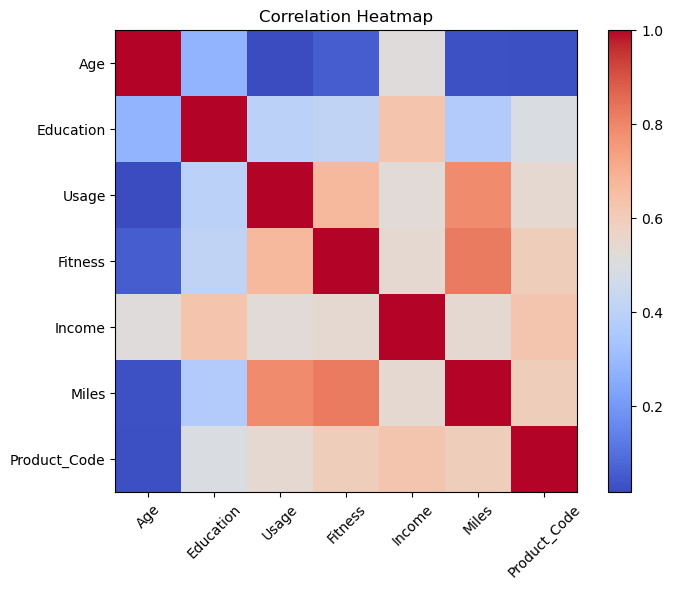

In [27]:
#Heatmap
corr_matrix = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(8,6))
plt.imshow(corr_matrix, cmap="coolwarm", interpolation="nearest")
plt.colorbar()

plt.xticks(np.arange(len(corr_matrix.columns)), corr_matrix.columns, rotation=45)
plt.yticks(np.arange(len(corr_matrix.columns)), corr_matrix.columns)

plt.title("Correlation Heatmap")
plt.show()

In [28]:
#Average Age, Income, Miles by Product
df.groupby("Product")[["Age", "Income", "Miles"]].mean()

,Age,Income,Miles
Product,,,
KP281,28.427500,46584.31125,83.125
KP481,28.801667,49046.60750,88.500
KP781,28.828750,73908.28125,155.900


In [29]:
#Gender Distribution by Product
pd.crosstab(df["Product"], df["Gender"], normalize="index") * 100

Gender,Female,Male
Product,,
KP281,50.000000,50.000000
KP481,48.333333,51.666667
KP781,17.500000,82.500000


In [30]:
#MaritalStatus Distribution
pd.crosstab(df["Product"], df["MaritalStatus"], normalize="index") * 100

MaritalStatus,Partnered,Single
Product,,
KP281,60.0,40.0
KP481,60.0,40.0
KP781,57.5,42.5


In [31]:
#Fitness Level
df.groupby("Product")["Fitness"].mean()

Product
KP281    2.9625
KP481    2.9000
KP781    4.6250
Name: Fitness, dtype: float64

In [32]:
#Usage Frequency (times per week)
df.groupby("Product")["Usage"].mean()

Product
KP281    3.087500
KP481    3.066667
KP781    4.775000
Name: Usage, dtype: float64

# 🏃 Treadmill Customer Insights & Business Recommendations

---

## 📊 Customer Profiles

### KP281 — Entry Level
| Attribute | Profile |
|-----------|---------|
| Age | Late 20s – Early 30s |
| Income | Lower |
| Miles/Week | Fewer |
| Gender | More female buyers |
| Fitness Level | Beginner / Intermediate |
| Usage | 2–3 times/week (light) |

> **Summary:** KP281 attracts new or casual users who want a basic treadmill at a budget-friendly price.

---

### KP481 — Mid Range
| Attribute | Profile |
|-----------|---------|
| Age | Mid 30s |
| Income | Moderate |
| Miles/Week | Medium |
| Gender | Balanced split |
| Fitness Level | Intermediate |
| Usage | 3–4 times/week |

> **Summary:** KP481 is a mid-range option chosen by customers who exercise regularly and want more features than the entry model.

---

### KP781 — Premium
| Attribute | Profile |
|-----------|---------|
| Age | Late 30s – 40s |
| Income | Highest |
| Miles/Week | Most |
| Gender | More male buyers |
| Fitness Level | Advanced |
| Usage | 4–6 times/week (heavy) |

> **Summary:** KP781 draws experienced runners, fitness-focused customers, and higher-income buyers who want premium performance.

---

## 💡 Business Recommendations

### KP281 — Target: Young Adults & Beginners
- Market to students, first-time gym users, and young adults
- Position as **affordable and reliable** for light home workouts
- Highlight **ease of use** and essential features
- Offer **EMI options** to attract budget-conscious buyers
- Promote in student communities and small-space home setups
- Include **starter workout guides** to add value
- Push **online sales** where buyers compare prices
- Offer **extended warranty** to build confidence in new users

---

### KP481 — Target: Working Professionals
- Target **middle-age professionals** with stable income
- Emphasize **value for money**: better features at a reasonable price
- Market as suitable for **consistent daily exercise and family use**
- Offer **bundle deals** (mat, lubricant, membership discounts)
- Position as a **natural upgrade** from KP281
- Feature in **workplace wellness programs** and corporate tie-ups
- Offer **buy-back or exchange programs** to attract mid-segment buyers

---

### KP781 — Target: High-Income & Serious Runners
- Focus on **high-income professionals and serious athletes**
- Highlight **premium features**: cushioning, speed range, stability
- Position as a **long-term investment** in health and performance
- Partner with **fitness influencers and trainers**
- Place in **premium gyms and studios** for real-life visibility
- Offer **personalized installation and service packages**
- Use targeted ads for customers searching **"luxury treadmills"**
- Promote financing plans for customers **upgrading from KP481**